In [1]:
"""Hydrangea demo object test script.

This runs inside the notebook. Do not hardcode the notebook path.
The data mount is fixed at /storage/dandi_downloads.
"""

from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pynapple as nap

from hybrid_dynamics_core.base import HybridDynamicsAnalysis

DOWNLOAD_DIR = Path("/storage/dandi_downloads").resolve()
MODEL_DIR = DOWNLOAD_DIR / "hydrangea_models"
DANDISET_ID = "001695"
VERSION_ID = "0.260319.2023"
SUBJECTS = ["sub-M01", "sub-M02", "sub-M03", "sub-M05"]

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def print_session_table(download_root: Path):
    rows = []
    for subject_dir in sorted(download_root.glob("sub-*")):
        for nwb_file in sorted(subject_dir.rglob("*.nwb")):
            rel = nwb_file.relative_to(download_root)
            parts = rel.parts
            if len(parts) >= 3:
                subject = parts[0]
                session = parts[1] if len(parts) > 1 else "unknown"
                date = parts[-2] if len(parts) > 2 else "unknown"
            else:
                subject = subject_dir.name
                session = "unknown"
                date = "unknown"
            rows.append((subject, session, date, str(nwb_file)))

    if not rows:
        print(f"No NWB files found under {download_root}")
        return

    print("\nDANDI session inventory")
    print("-" * 110)
    print(f"{'subject':<12} {'session':<20} {'date':<20} {'nwb_file':<80}")
    print("-" * 110)
    for subject, session, date, path in rows:
        print(f"{subject:<12} {session:<20} {date:<20} {path:<80}")
    print("-" * 110)


print_session_table(DOWNLOAD_DIR)



DANDI session inventory
--------------------------------------------------------------------------------------------------------------
subject      session              date                 nwb_file                                                                        
--------------------------------------------------------------------------------------------------------------
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb        
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240312T100000_behavior+ecephys.nwb
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240314T100000_behavior+ecephys.nwb
sub-M01      unknown              unknown              /storage/dandi_

Session NWB path: /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
Units before/after maze restriction: 240 / 240


/notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo/hybrid_dynamics_core/normalization.py:71: UserWarning: Dropped 3 neurons with no spikes in analyzed time interval. Per-region dropped counts -> CA1:1, CA3:2.
  warnings.warn(msg)


(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'Raw bin counts (population, log y)'}, xlabel='count', ylabel='freq'>,
         <Axes: title={'center': 'Fraction empty bins/neuron'}, xlabel='P(count=0)', ylabel='count'>,
         <Axes: title={'center': 'Mean vs var — raw'}, xlabel='mean', ylabel='var'>],
        [<Axes: title={'center': 'Normalized values (population, log y)'}, xlabel='z', ylabel='freq'>,
         <Axes: >,
         <Axes: title={'center': 'Total spikes/neuron (divisor)'}, xlabel='spike count', ylabel='count'>]],
       dtype=object))

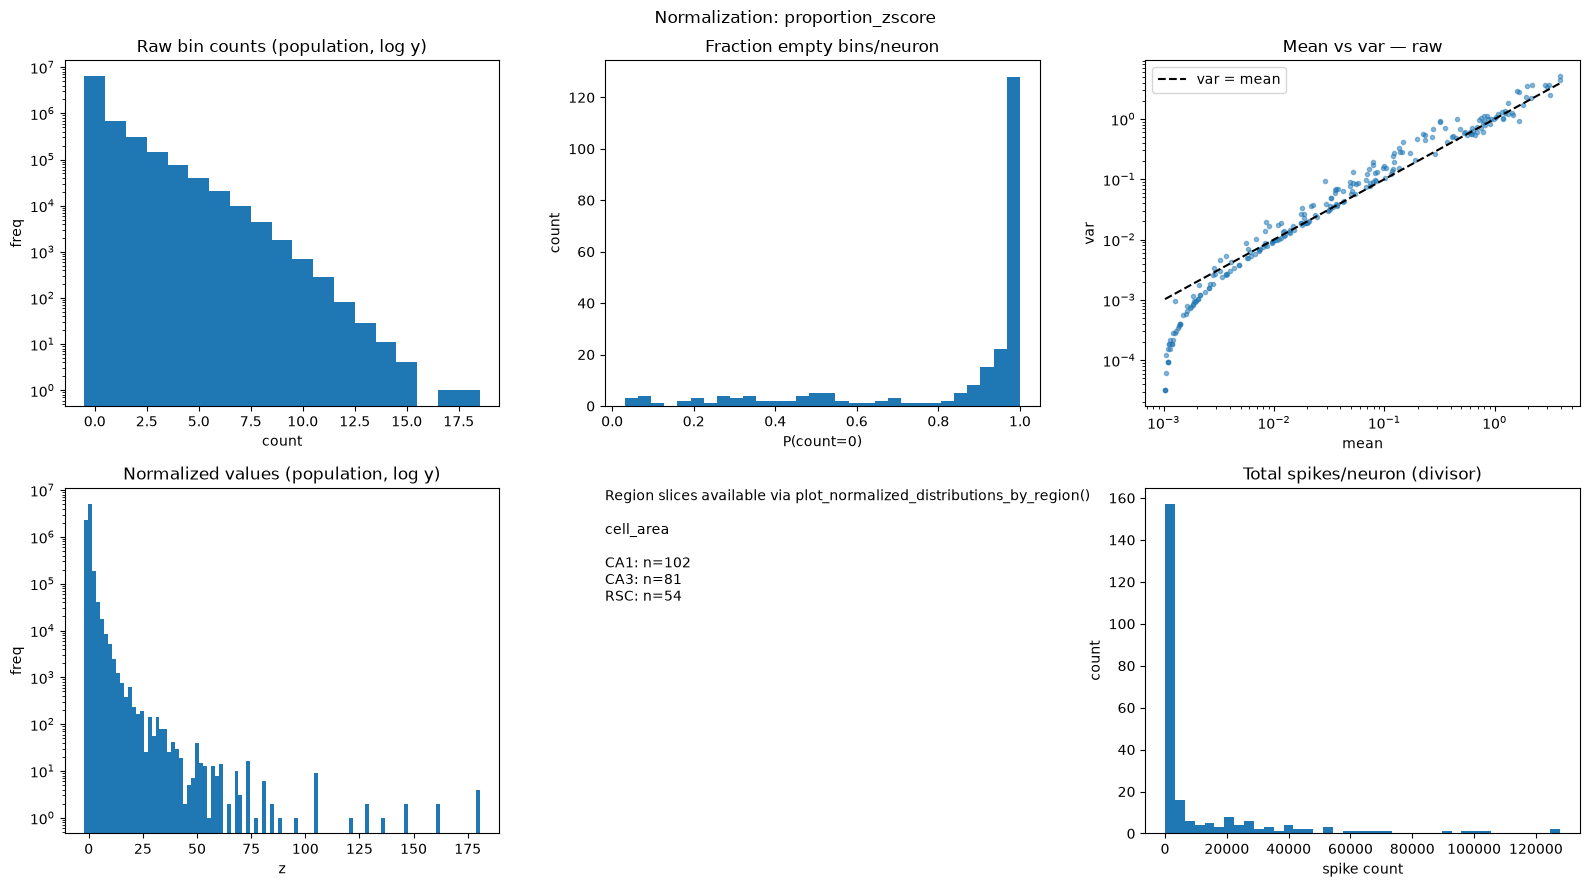

In [2]:

# Build the same session context used in the notebook.
# Hardcoded for the known dataset in this tutorial script.
session_nwb_path = Path(
    "/storage/dandi_downloads/sub-M01/"
    "sub-M01_ses-20240313T100000_behavior+ecephys.nwb"
).resolve()
session_nwb = nap.load_file(str(session_nwb_path))

spike_group = session_nwb["units"]
position_xy = session_nwb["Position"]

maze_start = float(position_xy.index[0])
maze_end = float(position_xy.index[-1])
maze_ep = nap.IntervalSet(start=maze_start, end=maze_end)
spike_group_maze = spike_group.restrict(maze_ep)

print("Session NWB path:", session_nwb_path)
print("Units before/after maze restriction:", len(spike_group), "/", len(spike_group_maze))

# Example usage: create a Hydrangea object and call steps in order.
hybdyn = HybridDynamicsAnalysis(
    spike_group=spike_group_maze,
    bin_size_s=0.050,
    maze_epoch=maze_ep,
    session_id="sub-M01_ses-20240313T100000",
    mouse_id="M01",
    embedding_method="pca",
    state_discovery_method="gaussian_hmm",
    random_state=0,
    report="selected",
)

# 1) normalize
hybdyn.normalize(method="proportion_zscore", zscore=True, restrict_to_epoch=True)
hybdyn.normalization_report(show=False)


In [ ]:

# 2) global embedding (PCA for now)
hybdyn.global_embedding(method="pca", n_components=10, whiten=False, standardize=True)
hybdyn.report_embeddings(show=False)

# 3) build folds
hybdyn.build_folds(
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    seed=0,
)

# 4) fit state-discovery model (locked method: gaussian_hmm)
hybdyn.fit_states(
    n_states_min=2,
    n_states_max=10,
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    n_iter=100,
    covariance_type="diag",
    verbose=False,
    use_cv=True,
    report="selected",
)

# Optional next step: local embedding inside one discovered state.
# hybdyn.local_embedding(state_labels=hybdyn.state_labels_, state_value=0, method="pca", label="state_0")
# hybdyn.report_embeddings(scope="local", label="state_0", show=False)

# 5) reporting
hybdyn.hmm_report(report="selected")
# hybdyn.hmm_report(report="full")
# hybdyn.hmm_report(report="none")

# 6) save and reload the selected model
saved_model_path = MODEL_DIR / f"{session_nwb_path.stem}_best_hmm.pkl"
hybdyn.save_hmm_model(saved_model_path)
reloaded_artifact = hybdyn.load_hmm_model(saved_model_path)

print("Saved model path:", saved_model_path)
print("Reloaded model states:", reloaded_artifact["n_states"])

print("Notebook working directory:", ROOT)
print("Download dir:", DOWNLOAD_DIR)
print("Best K:", hybdyn.best_k)
print("Model count:", len(hybdyn.hmm_models))

# 7) object summary for workflow tracking
hybdyn.describe(as_text=True)
